## Build a basic ChatBot with langgraph(Graph API)

In [10]:
from typing import Annotated # Annotated is used for type annotations with additional metadata
from typing_extensions import TypedDict # TypedDict is used to define a dictionary with specific keys and value types

from langgraph.graph import StateGraph, START, END # StateGraph is a class for managing a graph of states, START and END are constants representing the starting and ending states
from langgraph.graph.message import add_messages # add_messages is a function (reducers) to add messages to the graph

In [11]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State) # Create a new StateGraph with the defined State type

In [5]:
graph_builder

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama3-8b-8192")

In [20]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1102a9950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1102aa5d0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1111bd090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1111bda90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [27]:
## node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [ ]:
graph_builder = StateGraph(State) # Create a new StateGraph with the defined State type

## Addning node
graph_builder.add_node("llmchatbot", chatbot) # Add a node to the graph with the name "llmchatbot" and the functionality defined in the chatbot function

## Adding Edge
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

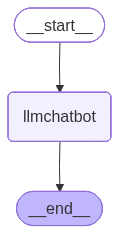

In [29]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [30]:
response=graph.invoke({"messages":"Hi"})

In [31]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='d7ce5556-d954-46ae-a53f-ca8979884791'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 36, 'total_tokens': 60, 'completion_time': 0.062695601, 'completion_tokens_details': None, 'prompt_time': 0.000995471, 'prompt_tokens_details': None, 'queue_time': 0.054321179, 'total_time': 0.063691072}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8b76-9c1b-7471-ac08-53fdde70a692-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 24, 'total_tokens': 60})]}

In [32]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

In [ ]:
# graph.stream() returns an iterator of events that occur as the graph processes the input. Each event is a dictionary containing information about the current state of the graph, including any messages that have been generated.

for event in graph.stream({"messages":"Hello, how are you?"}): 
    print(event)


{'llmchatbot': {'messages': [AIMessage(content="Hello, I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 41, 'total_tokens': 99, 'completion_time': 0.128349035, 'completion_tokens_details': None, 'prompt_time': 0.002119648, 'prompt_tokens_details': None, 'queue_time': 0.162235041, 'total_time': 0.130468683}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8b83-2910-7061-be98-fda1bfc9a28e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 58, 'total_tokens': 99})]}}


In [ ]:
for event in graph.stream({"messages":"Hello, how are you?"}): 
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 41, 'total_tokens': 89, 'completion_time': 0.098287349, 'completion_tokens_details': None, 'prompt_time': 0.002230732, 'prompt_tokens_details': None, 'queue_time': 0.051199377, 'total_time': 0.100518081}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8b84-e6c8-7143-8b5f-943ca62fbefe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 48, 'total_tokens': 89})]}


In [35]:
for event in graph.stream({"messages":"Hello, how are you?"}): 
    for value in event.values():
        print(value["messages"][-1].content) # only ai message content will be displayed

Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or topics you'd like to discuss. How can I help you today?


## ChatBot with tools

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is langchain?")

{'query': 'What is langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.coursera.org/articles/what-is-langchain',
   'title': 'What Is LangChain? | Coursera',
   'content': 'Expand your knowledge of LangChain, discover its main applications, and explore the potential advantages and disadvantages of utilizing the tool. LangChain is a framework for developing applications driven by large language models (LLMs). It’s available in the Python and JavaScript libraries and can aid in the development of applications such as chatbots and virtual agents. According to IBM, “LangChain enjoyed a meteoric rise to prominence: as of June 2023, it was the single fastest-growing open source project on GitHub. Coinciding with the momentous launch of OpenAI’s ChatGPT the following month, LangChain has played a significant role in making generative AI more accessible to enthusiasts in the wake of its widespread popularity” [1]. Explore LangChain’s fra

In [5]:
## custom function

def multiply(a: int, b: int) -> int:
    """multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: the product of a and b
    """
    return a * b

In [7]:
tools = [tool, multiply]

llm_with_tools = llm.bind_tools(tools)

llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1111bd090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1111bda90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-tim

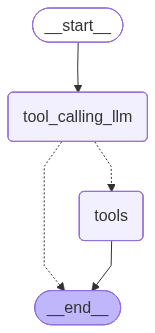

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools", END)

# compile the graph
graph = builder.compile()


from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
response=graph.invoke({"messages":"What is the recent ai news"})
response

{'messages': [HumanMessage(content='What is the recent ai news', additional_kwargs={}, response_metadata={}, id='604a52b6-2c08-4927-b50b-2124397ca439'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4af7yfk28', 'function': {'arguments': '{"query":"recent ai news","search_depth":"basic","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1751, 'total_tokens': 1789, 'completion_time': 0.11291619, 'completion_tokens_details': None, 'prompt_time': 0.09865302, 'prompt_tokens_details': None, 'queue_time': 0.051075709, 'total_time': 0.21156921}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e90ab-d8b8-72d3-998f-d210536f2cff-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent ai news', 'search_dept

In [16]:
response["messages"][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/ubeya-highlights-ai-driven-workforce-analytics-capability", "title": "Ubeya Highlights AI-Driven Workforce Analytics Capability - TipRanks", "score": 0.6158511, "published_date": "Wed, 03 Jun 2026 12:04:41 GMT", "content": "# Ubeya Highlights AI-Driven Workforce Analytics Capability. According to a recent LinkedIn post from Ubeya, the company is highlighting a new AI-driven feature called Ubeya AI Insights aimed at simplifying workforce data analysis. * Unlock trusted, data-backed investing tools with TipRanks Premium, from analyst ratings and forecasts to breaking news and portfolio analysis. * Discover high-conviction stock picks and new investing opportunities with the TipRanks Smart Investor Newsletter. The post suggests that AI Insights is intended to deliver instant answers and reveal operational trends without the need to ma

In [17]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (4af7yfk28)
 Call ID: 4af7yfk28
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/ubeya-highlights-ai-driven-workforce-analytics-capability", "title": "Ubeya Highlights AI-Driven Workforce Analytics Capability - TipRanks", "score": 0.6158511, "published_date": "Wed, 03 Jun 2026 12:04:41 GMT", "content": "# Ubeya Highlights AI-Driven Workforce Analytics Capability. According to a recent LinkedIn post from Ubeya, the company is highlighting a new AI-driven feature called Ubeya 

In [18]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (03t6vghs0)
 Call ID: 03t6vghs0
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [19]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (s8s1mary6)
 Call ID: s8s1mary6
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
  multiply (k0tftz4wc)
 Call ID: k0tftz4wc
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aibusiness.com/responsible-ai/ai-ethics", "title": "AI Ethics recent news", "content": "Explore the latest news and expert commentary on AI Ethics, brought to you by the editors of AI Business.", "score": 0.6578248, "raw_content": null}, {"url": "https://www.facebook.com/techinsider/posts/sam-altman-said-ai-budgeting-has-recently-become-a-huge-issue-for-so